# Week 11 · Day 2 — R-CNN Family
### Object Detection with Deep Learning | June 16, 2026 | Remote

**Week 11 Theme:** Object Detection with Deep Learning  
**Daily Deliverable:** Faster R-CNN inference on COCO  
**Repository:** `03_June/Week_03/`

---

> *"The R-CNN family solved detection by treating it as a region classification problem — each iteration removing one bottleneck at a time until the entire pipeline became a single end-to-end trainable network."*

---

## The R-CNN Evolution at a Glance

```
R-CNN (2014)                Fast R-CNN (2015)           Faster R-CNN (2016)
─────────────────           ─────────────────────       ──────────────────────────
Image                       Image                       Image
  │                           │                           │
Selective Search (CPU)       CNN (full image)            CNN (full image)
  │ ~2000 proposals           │ feature map              │ feature map
  ▼                           │                           │
Warp 2000×227×227             │                         RPN ← learnable proposals
  │                           │ ROI Pooling               │
CNN ×2000 (slow!)             │ (one pass!)             ROI Align
  │                           │                           │
SVM per class                Cls + Reg heads            Cls + Reg heads
  │ (separate)                │ (joint, end-to-end)       │ (joint, end-to-end)
BBox regressor              ──────────────────         ──────────────────────────
──────────────               2.3 s/image               0.2 s/image
47 s/image                   ~20× faster               ~10× faster than Fast
```

## Learning Objectives

| # | Concept | What We Build |
|---|---------|---------------|
| 1 | R-CNN pipeline | Selective search simulation + bottleneck analysis |
| 2 | Fast R-CNN | ROI Pooling from scratch |
| 3 | Faster R-CNN | Region Proposal Network (RPN) implementation |
| 4 | ROI Align | Bilinear interpolation — fixes ROI Pool misalignment |
| 5 | Multi-task loss | Classification + regression combined objective |
| 6 | Faster R-CNN inference | torchvision model inspection + forward pass |

---

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models.detection as det_models
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print(f'PyTorch {torch.__version__} | torchvision {torchvision.__version__}')

PyTorch 2.12.0+cpu | torchvision 0.27.0+cpu


---
## 1. R-CNN (Girshick et al., 2014)

### The Idea
R-CNN was the first to combine region proposals with CNN features for detection. The insight: use a CNN to extract rich features from each proposed region, then classify with a linear SVM.

### Pipeline
1. **Selective Search** generates ~2000 region proposals per image using hierarchical image segmentation (merging similar regions based on colour, texture, size)
2. Each proposal is **warped to 227×227** (AlexNet input size) — loses aspect ratio
3. **AlexNet forward pass** for each → 4096-dim feature vector → 2000 passes per image
4. **SVM classifier** trained separately for each class on extracted features
5. **Bounding box regressor** trained separately to refine proposal coordinates

### Why R-CNN was slow (47 s/image)
- 2000 independent CNN forward passes per image
- Training is multi-stage — CNN, SVM, regressor are all separate
- Selective search runs on CPU — not part of the GPU pipeline
- Warp destroys spatial information (fixed to 227×227)

### Key formula — Bounding Box Regression
R-CNN trains a linear regressor to map proposal coordinates `(Px, Py, Pw, Ph)` to target offsets:
$$t_x = (G_x - P_x)/P_w, \quad t_y = (G_y - P_y)/P_h$$
$$t_w = \log(G_w/P_w), \quad t_h = \log(G_h/P_h)$$
This log-space transformation for width/height makes the regression scale-invariant — same as what anchors use in Faster R-CNN.

In [2]:
# ─── Selective Search Simulation ────────────────────────────────────────────
# Real selective search uses hierarchical region merging (colour, texture, size, fill).
# We simulate the proposal distribution: many small boxes + fewer large ones.

def simulate_selective_search(img_h, img_w, n_proposals=2000, seed=42):
    """Simulate the spatial distribution of selective search proposals."""
    rng = np.random.RandomState(seed)
    proposals = []
    for _ in range(n_proposals):
        # Sample box size: skewed toward smaller boxes (realistic for sel. search)
        w = int(np.clip(rng.exponential(scale=img_w * 0.25), 30, img_w - 1))
        h = int(np.clip(rng.exponential(scale=img_h * 0.25), 30, img_h - 1))
        x1 = rng.randint(0, max(1, img_w - w))
        y1 = rng.randint(0, max(1, img_h - h))
        proposals.append([x1, y1, x1+w, y1+h])
    return np.array(proposals)

IMG_H, IMG_W = 400, 600
proposals = simulate_selective_search(IMG_H, IMG_W, n_proposals=2000)

# Size distribution of proposals
widths  = proposals[:,2] - proposals[:,0]
heights = proposals[:,3] - proposals[:,1]
areas   = widths * heights

print(f'Total proposals : {len(proposals)}')
print(f'Width  range    : {widths.min():.0f} - {widths.max():.0f} px  (mean {widths.mean():.0f})')
print(f'Height range    : {heights.min():.0f} - {heights.max():.0f} px  (mean {heights.mean():.0f})')
print(f'Area   range    : {areas.min():.0f} - {areas.max():.0f} px2')
print()
print('R-CNN bottleneck:')
print(f'  CNN forward passes per image : {len(proposals)}')
print(f'  AlexNet time per pass (CPU)  : ~23 ms')
print(f'  Total CNN time               : {len(proposals) * 23 / 1000:.0f} s  <- the bottleneck!')

Total proposals : 2000
Width  range    : 30 - 599 px  (mean 150)
Height range    : 30 - 399 px  (mean 100)
Area   range    : 900 - 239001 px2

R-CNN bottleneck:
  CNN forward passes per image : 2000
  AlexNet time per pass (CPU)  : ~23 ms
  Total CNN time               : 46 s  <- the bottleneck!


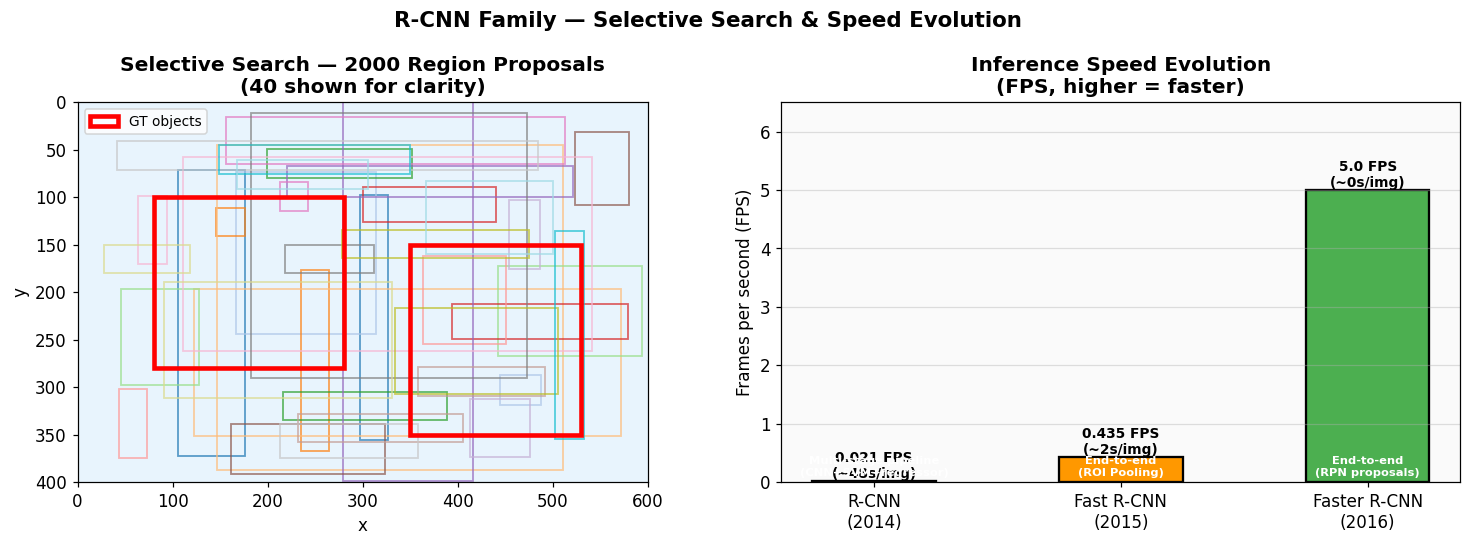

Saved: rcnn_evolution.png


In [3]:
# ─── R-CNN Visualisation ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: region proposals on image
ax = axes[0]
ax.set_xlim(0, IMG_W); ax.set_ylim(IMG_H, 0)
ax.set_facecolor('#E8F4FD'); ax.set_aspect('equal')
ax.set_title('Selective Search — 2000 Region Proposals\n(40 shown for clarity)', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')

cmap = plt.cm.tab20
show_idx = np.linspace(0, len(proposals)-1, 40, dtype=int)
for k, i in enumerate(show_idx):
    p = proposals[i]
    r = patches.Rectangle((p[0],p[1]), p[2]-p[0], p[3]-p[1],
                           linewidth=1.2, edgecolor=cmap(k/40),
                           facecolor='none', alpha=0.7)
    ax.add_patch(r)

# Draw two 'ground truth' objects as thick boxes
gt1 = patches.Rectangle((80, 100), 200, 180, lw=3, edgecolor='red', facecolor='none', label='GT objects')
gt2 = patches.Rectangle((350, 150), 180, 200, lw=3, edgecolor='red', facecolor='none')
ax.add_patch(gt1); ax.add_patch(gt2)
ax.legend(fontsize=9)

# Right: R-CNN bottleneck comparison bar chart
ax = axes[1]
methods = ['R-CNN\n(2014)', 'Fast R-CNN\n(2015)', 'Faster R-CNN\n(2016)']
fps     = [0.021, 0.435, 5.0]     # frames per second (approx.)
colors  = ['#F44336', '#FF9800', '#4CAF50']

bars = ax.bar(methods, fps, color=colors, edgecolor='black', linewidth=1.5, width=0.5)
ax.set_title('Inference Speed Evolution\n(FPS, higher = faster)', fontweight='bold')
ax.set_ylabel('Frames per second (FPS)')
ax.set_facecolor('#FAFAFA'); ax.grid(True, axis='y', alpha=0.4)
for bar, v in zip(bars, fps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
           f'{v} FPS\n(~{1/v:.0f}s/img)', ha='center', fontweight='bold', fontsize=9)
ax.set_ylim(0, 6.5)

labels = ['Multi-stage pipeline\n(CNN+SVM+regressor)',
          'End-to-end\n(ROI Pooling)',
          'End-to-end\n(RPN proposals)']
for bar, lbl in zip(bars, labels):
    ax.text(bar.get_x()+bar.get_width()/2, 0.08, lbl,
           ha='center', va='bottom', fontsize=7.5, color='white', fontweight='bold')

plt.suptitle('R-CNN Family — Selective Search & Speed Evolution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rcnn_evolution.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: rcnn_evolution.png')

---
## 2. Fast R-CNN (Girshick, 2015)

### The Key Insight
R-CNN passes each proposal through the CNN separately — 2000 forward passes per image. **Fast R-CNN inverts this**: run the CNN **once on the full image**, then extract proposal features from the resulting feature map using **ROI Pooling**.

### ROI Pooling
ROI Pooling maps a variable-size region of the feature map to a **fixed-size output** (e.g. 7×7) using max-pooling:

```
ROI in image space: [x1=128, y1=96, x2=320, y2=256]
Backbone stride: 16 → feature coords: [8, 6, 20, 16]
Divide 12×14 region into 7×7 bins  →  max-pool each bin
Output: 7×7×C (same size regardless of ROI dimensions)
```

**Problem with ROI Pooling:** The `round()` operation on feature map coordinates causes **quantization error** — up to half a stride (8 pixels for stride-16 backbone). This misalignment hurts small object detection and segmentation accuracy.

### Multi-task Loss (end-to-end training)

$$L = L_{cls} + \lambda \cdot L_{loc}$$

- $L_{cls}$ — log-loss over K+1 classes (K classes + background)
- $L_{loc}$ — Smooth L1 loss on box offsets (only for non-background proposals):

$$\text{Smooth L1}(x) = \begin{cases} 0.5x^2 & |x| < 1 \\ |x| - 0.5 & \text{otherwise} \end{cases}$$

Smooth L1 is less sensitive to outlier boxes than L2 loss — large errors are penalised linearly, not quadratically.

In [4]:
# ─── ROI Pooling from Scratch ────────────────────────────────────────────────

def roi_pool(feat_map, rois, pool_size=(7,7), spatial_scale=1/16):
    """
    ROI Pooling: project image-space ROI to feature map, then max-pool to fixed size.

    feat_map     : np.ndarray (C, fH, fW)
    rois         : list of [x1, y1, x2, y2] in image coordinates
    pool_size    : (oh, ow) — fixed output height/width
    spatial_scale: feature_map_size / image_size  (1/16 for stride-16 backbone)

    Returns: np.ndarray (N, C, oh, ow)

    Key limitation: int(round(...)) QUANTIZES coordinates → causes misalignment.
    ROI Align fixes this with bilinear interpolation (see Section 4).
    """
    C, fH, fW = feat_map.shape
    oh, ow = pool_size
    N = len(rois)
    out = np.zeros((N, C, oh, ow), dtype=np.float32)

    for i, roi in enumerate(rois):
        # Map to feature map coordinates — QUANTIZED (source of misalignment)
        x1 = max(0, int(round(roi[0] * spatial_scale)))
        y1 = max(0, int(round(roi[1] * spatial_scale)))
        x2 = min(fW, int(round(roi[2] * spatial_scale)))
        y2 = min(fH, int(round(roi[3] * spatial_scale)))

        roi_w = max(x2 - x1, 1)
        roi_h = max(y2 - y1, 1)

        # Divide into oh×ow bins, max-pool each bin
        for r in range(oh):
            for c in range(ow):
                r1 = y1 + int(np.floor(r     * roi_h / oh))
                r2 = y1 + int(np.ceil ((r+1) * roi_h / oh))
                c1 = x1 + int(np.floor(c     * roi_w / ow))
                c2 = x1 + int(np.ceil ((c+1) * roi_w / ow))
                r1 = min(max(r1, 0), fH); r2 = min(max(r2, 0), fH)
                c1 = min(max(c1, 0), fW); c2 = min(max(c2, 0), fW)
                if r2 > r1 and c2 > c1:
                    out[i, :, r, c] = feat_map[:, r1:r2, c1:c2].max(axis=(1,2))

    return out


def smooth_l1_loss(pred, target, beta=1.0):
    """Smooth L1 loss used for bounding box regression."""
    diff = np.abs(pred - target)
    return np.where(diff < beta, 0.5 * diff**2 / beta, diff - 0.5 * beta)


# ─── Demo ────────────────────────────────────────────────────────────────────
# Synthetic feature map: 1 channel, 40×60 (equivalent to 640×960 image at stride-16)
np.random.seed(5)
feat_map = np.random.rand(1, 40, 60).astype(np.float32)

# Three ROIs of different sizes and aspect ratios (image coordinates)
rois = [
    [80,  64, 320, 256],   # large box
    [200, 180, 360, 300],  # medium box
    [400, 50,  540, 180],  # wide box
]

pooled = roi_pool(feat_map, rois, pool_size=(4, 4), spatial_scale=1/16)

print('ROI Pooling results:')
print(f'  Feature map   : {feat_map.shape}  (1×40×60)')
print(f'  Spatial scale : 1/16  (image stride = 16 pixels)')
for j, roi in enumerate(rois):
    w = roi[2]-roi[0]; h = roi[3]-roi[1]
    print(f'  ROI {j}  [{roi[0]},{roi[1]},{roi[2]},{roi[3]}]  '
          f'size={w}×{h} px  →  pooled {pooled[j].shape}')
print(f'  All ROIs produce the same output size: {pooled.shape[1:]} ✓')

# Smooth L1 demo
x = np.linspace(-3, 3, 200)
sl1 = smooth_l1_loss(x, 0.0)
l2  = 0.5 * x**2
print(f'\nSmooth L1 vs L2 at x=2.0: SL1={smooth_l1_loss(2.0,0.0):.3f}  L2={0.5*4:.3f}')
print('Smooth L1 penalises large errors linearly (not quadratically) — more robust to outlier boxes.')

ROI Pooling results:
  Feature map   : (1, 40, 60)  (1×40×60)
  Spatial scale : 1/16  (image stride = 16 pixels)
  ROI 0  [80,64,320,256]  size=240×192 px  →  pooled (1, 4, 4)
  ROI 1  [200,180,360,300]  size=160×120 px  →  pooled (1, 4, 4)
  ROI 2  [400,50,540,180]  size=140×130 px  →  pooled (1, 4, 4)
  All ROIs produce the same output size: (1, 4, 4) ✓

Smooth L1 vs L2 at x=2.0: SL1=1.500  L2=2.000
Smooth L1 penalises large errors linearly (not quadratically) — more robust to outlier boxes.


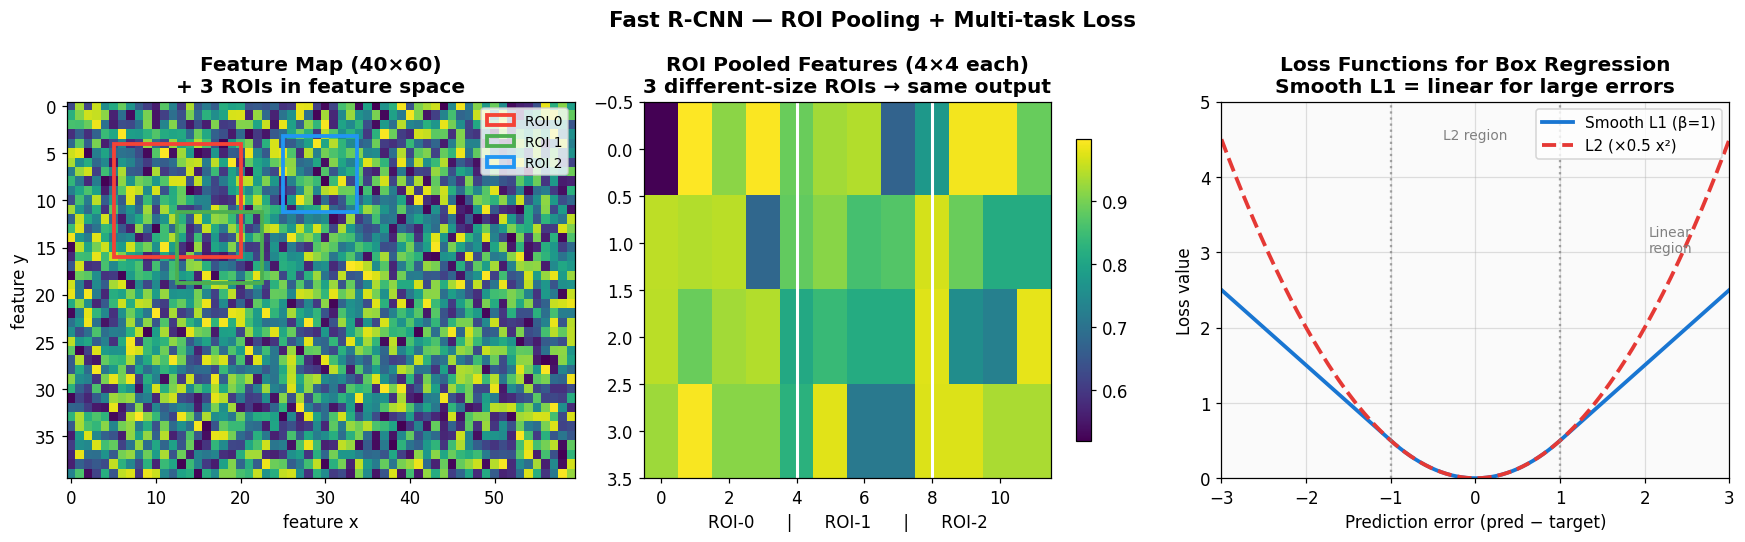

Saved: roi_pool_viz.png


In [5]:
# ─── ROI Pooling + Smooth L1 Visualisation ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: feature map + ROI boxes
ax = axes[0]
ax.imshow(feat_map[0], cmap='viridis', aspect='auto', origin='upper')
ax.set_title('Feature Map (40×60)\n+ 3 ROIs in feature space', fontweight='bold')
ax.set_xlabel('feature x'); ax.set_ylabel('feature y')
roi_colors = ['#F44336', '#4CAF50', '#2196F3']
for j, roi in enumerate(rois):
    fx1 = roi[0]/16; fy1 = roi[1]/16
    fw  = (roi[2]-roi[0])/16; fh = (roi[3]-roi[1])/16
    r = patches.Rectangle((fx1, fy1), fw, fh,
                           lw=2.5, edgecolor=roi_colors[j], facecolor='none',
                           label=f'ROI {j}')
    ax.add_patch(r)
ax.legend(fontsize=9, loc='upper right')

# Mid: pooled features (3 ROIs × 4×4)
ax = axes[1]
combined = np.concatenate([pooled[j, 0] for j in range(3)], axis=1)
im = ax.imshow(combined, cmap='viridis', aspect='auto')
ax.set_title('ROI Pooled Features (4×4 each)\n3 different-size ROIs → same output', fontweight='bold')
ax.set_xlabel('ROI-0      |      ROI-1      |      ROI-2')
ax.axvline(4, color='white', lw=2); ax.axvline(8, color='white', lw=2)
plt.colorbar(im, ax=ax, shrink=0.8)

# Right: Smooth L1 vs L2 loss
ax = axes[2]
ax.plot(x, sl1, color='#1976D2', lw=2.5, label='Smooth L1 (β=1)')
ax.plot(x, l2,  color='#E53935', lw=2.5, linestyle='--', label='L2 (×0.5 x²)')
ax.set_title('Loss Functions for Box Regression\nSmooth L1 = linear for large errors', fontweight='bold')
ax.set_xlabel('Prediction error (pred − target)')
ax.set_ylabel('Loss value')
ax.legend(fontsize=10); ax.grid(True, alpha=0.4)
ax.set_facecolor('#FAFAFA'); ax.set_xlim(-3, 3); ax.set_ylim(0, 5)
ax.axvline(-1, color='gray', ls=':', lw=1.5, alpha=0.7)
ax.axvline( 1, color='gray', ls=':', lw=1.5, alpha=0.7)
ax.text(0, 4.5, 'L2 region', ha='center', color='gray', fontsize=9)
ax.text(2.3, 3, 'Linear\nregion', ha='center', color='gray', fontsize=9)

plt.suptitle('Fast R-CNN — ROI Pooling + Multi-task Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roi_pool_viz.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: roi_pool_viz.png')

---
## 3. Faster R-CNN — Region Proposal Network (RPN)

### The Final Bottleneck
Fast R-CNN is fast at feature extraction — but selective search (CPU, ~2 seconds) is still the bottleneck. **Faster R-CNN replaces selective search with a learned neural network: the RPN.**

### RPN Architecture
The RPN **shares the backbone feature map** with the detection head — no extra computation for proposals:

```
Backbone feature map  (B, C, H, W)
        │
  3×3 conv (same)  ─── shared sliding window
        │
   ┌────┴────┐
   │         │
 cls head  reg head
   │         │
(B,2A,H,W) (B,4A,H,W)
   │         │
objectness  Δx,Δy,Δw,Δh
(bg vs fg)  per anchor
```

**A** = number of anchors per cell (typically 9 = 3 scales × 3 ratios)

### RPN Training
- **Positive anchor:** IoU ≥ 0.7 with any GT box → foreground
- **Negative anchor:** IoU < 0.3 with all GT boxes → background
- **Ignore:** 0.3 ≤ IoU < 0.7 — neither positive nor negative
- **Mini-batch:** 256 anchors per image (128 positive, 128 negative — balanced sampling)

### 4-Step Alternating Training (original paper)
1. Train RPN (ImageNet backbone init)
2. Train Fast R-CNN using proposals from step 1
3. Fine-tune only RPN, backbone shared
4. Fine-tune only detection head, backbone fixed

Modern PyTorch training uses **joint end-to-end training** instead.

In [6]:
# ─── Region Proposal Network (RPN) ──────────────────────────────────────────

class RegionProposalNetwork(nn.Module):
    """
    RPN — Faster R-CNN (Ren et al., 2016).

    Slides a 3×3 window over the backbone feature map.
    At each spatial location, predicts for every anchor:
      - objectness logits  : [bg_score, fg_score]  (2 per anchor)
      - box deltas         : [Δx, Δy, Δw, Δh]      (4 per anchor)
    """
    def __init__(self, in_channels=256, num_anchors=9):
        super().__init__()
        # Shared 3×3 conv — same padding keeps spatial dims unchanged
        self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        # Objectness: 2 logits per anchor (background / foreground)
        self.cls  = nn.Conv2d(in_channels, num_anchors * 2, kernel_size=1)
        # Box regression: 4 deltas per anchor
        self.reg  = nn.Conv2d(in_channels, num_anchors * 4, kernel_size=1)

        for layer in [self.conv, self.cls, self.reg]:
            nn.init.normal_(layer.weight, std=0.01)
            nn.init.zeros_(layer.bias)

    def forward(self, feat):
        x = F.relu(self.conv(feat))
        objectness = self.cls(x)    # (B, 2A, H, W)
        box_deltas = self.reg(x)    # (B, 4A, H, W)
        return objectness, box_deltas


# ─── Demo ────────────────────────────────────────────────────────────────────
# Simulate the feature map output from a stride-16 backbone
# Image: 512×512  →  feature map: 32×32
B, C, fH, fW = 1, 256, 32, 32
NUM_ANCHORS = 9   # 3 scales × 3 ratios

rpn = RegionProposalNetwork(in_channels=C, num_anchors=NUM_ANCHORS)
feat = torch.randn(B, C, fH, fW)

with torch.no_grad():
    obj_logits, box_deltas = rpn(feat)

# Convert objectness logits → foreground probability
obj_probs = torch.softmax(obj_logits.view(B, NUM_ANCHORS, 2, fH, fW), dim=2)
fg_probs  = obj_probs[:, :, 1, :, :]   # foreground probability per anchor per cell

total_anchors = fH * fW * NUM_ANCHORS
print(f'Feature map          : {(B, C, fH, fW)}')
print(f'Anchors per cell     : {NUM_ANCHORS}  (3 scales × 3 ratios)')
print(f'Total anchors        : {fH}×{fW}×{NUM_ANCHORS} = {total_anchors:,}')
print()
print(f'Objectness output    : {list(obj_logits.shape)}  → (B, A×2, H, W)')
print(f'Box delta output     : {list(box_deltas.shape)}  → (B, A×4, H, W)')
print()

# After NMS on RPN proposals, top-K (e.g. 300) are passed to detection head
# High fg_prob → proposal passed forward;  low fg_prob → pruned
fg_max = fg_probs.max().item()
fg_mean = fg_probs.mean().item()
print(f'Foreground prob (untrained):  max={fg_max:.4f}  mean={fg_mean:.4f}')
print('After training, high-scoring cells correspond to real object locations.')

rpn_params = sum(p.numel() for p in rpn.parameters())
print(f'\nRPN parameters: {rpn_params:,}  (tiny — shares backbone computation)')

Feature map          : (1, 256, 32, 32)
Anchors per cell     : 9  (3 scales × 3 ratios)
Total anchors        : 32×32×9 = 9,216

Objectness output    : [1, 18, 32, 32]  → (B, A×2, H, W)
Box delta output     : [1, 36, 32, 32]  → (B, A×4, H, W)

Foreground prob (untrained):  max=0.5638  mean=0.5005
After training, high-scoring cells correspond to real object locations.

RPN parameters: 603,958  (tiny — shares backbone computation)


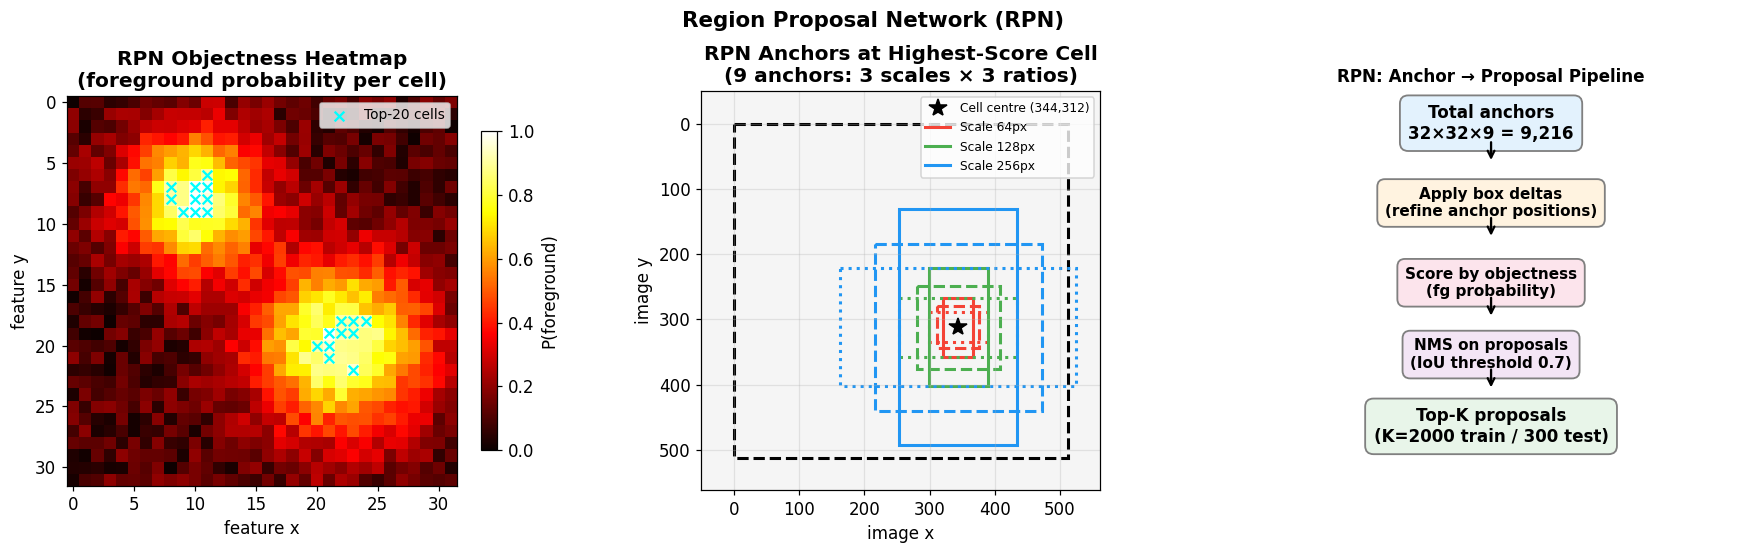

Saved: rpn_visualization.png


In [7]:
# ─── RPN Visualisation ──────────────────────────────────────────────────────

# Simulate a 'trained' objectness map: high scores near two object centres
np.random.seed(9)
obj_map = np.random.rand(fH, fW) * 0.2   # background noise

# Two synthetic object centres
for cx, cy, r in [(10, 8, 4), (22, 20, 5)]:
    Y, X = np.ogrid[:fH, :fW]
    dist = np.sqrt((X-cx)**2 + (Y-cy)**2)
    obj_map += np.exp(-dist**2 / (2 * r**2)) * 0.85
obj_map = obj_map.clip(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: objectness heatmap
ax = axes[0]
im = ax.imshow(obj_map, cmap='hot', vmin=0, vmax=1)
ax.set_title('RPN Objectness Heatmap\n(foreground probability per cell)', fontweight='bold')
ax.set_xlabel('feature x'); ax.set_ylabel('feature y')
plt.colorbar(im, ax=ax, shrink=0.8, label='P(foreground)')

# Mark top-scoring cells
top_k = 20
flat  = obj_map.flatten()
top_idx = np.argsort(flat)[-top_k:]
ty, tx = np.unravel_index(top_idx, obj_map.shape)
ax.scatter(tx, ty, c='cyan', s=40, marker='x', lw=1.5, label=f'Top-{top_k} cells')
ax.legend(fontsize=9)

# Mid: anchor boxes at the top objectness cell
ax = axes[1]
ax.set_title('RPN Anchors at Highest-Score Cell\n(9 anchors: 3 scales × 3 ratios)', fontweight='bold')
IMG_SZ = 512
ax.set_xlim(-50, IMG_SZ+50); ax.set_ylim(IMG_SZ+50, -50)
ax.set_aspect('equal'); ax.set_facecolor('#F5F5F5'); ax.grid(True, alpha=0.3)
ax.set_xlabel('image x'); ax.set_ylabel('image y')

img_rect = patches.Rectangle((0,0), IMG_SZ, IMG_SZ, lw=2, edgecolor='black', facecolor='none', ls='--')
ax.add_patch(img_rect)

best_cell = (ty[-1], tx[-1])
stride = 16
cx_img = (best_cell[1] + 0.5) * stride
cy_img = (best_cell[0] + 0.5) * stride

scales = [64, 128, 256]
ratios = [0.5, 1.0, 2.0]
sc_colors = ['#F44336', '#4CAF50', '#2196F3']
rt_styles  = ['-', '--', ':']

for si, sc in enumerate(scales):
    for ri, rt in enumerate(ratios):
        w = sc * np.sqrt(rt); h = sc / np.sqrt(rt)
        rect = patches.Rectangle((cx_img-w/2, cy_img-h/2), w, h,
                                  lw=2, edgecolor=sc_colors[si],
                                  facecolor='none', linestyle=rt_styles[ri])
        ax.add_patch(rect)

ax.plot(cx_img, cy_img, 'k*', ms=12, zorder=6, label=f'Cell centre ({cx_img:.0f},{cy_img:.0f})')
for si, sc in enumerate(scales):
    ax.plot([], [], color=sc_colors[si], lw=2, label=f'Scale {sc}px')
ax.legend(fontsize=8, loc='upper right')

# Right: RPN → proposal selection pipeline
ax = axes[2]
ax.axis('off')
ax.set_facecolor('#FAFAFA')
steps = [
    (0.5, 0.92, 'Total anchors\n32×32×9 = 9,216', '#E3F2FD', 11),
    (0.5, 0.72, 'Apply box deltas\n(refine anchor positions)', '#FFF3E0', 10),
    (0.5, 0.52, 'Score by objectness\n(fg probability)', '#FCE4EC', 10),
    (0.5, 0.34, 'NMS on proposals\n(IoU threshold 0.7)', '#F3E5F5', 10),
    (0.5, 0.16, 'Top-K proposals\n(K=2000 train / 300 test)', '#E8F5E9', 11),
]
for (x_pos, y_pos, text, color, fs) in steps:
    ax.text(x_pos, y_pos, text, transform=ax.transAxes, ha='center', va='center',
           fontsize=fs, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='gray', lw=1.2))

for y_pos in [0.82, 0.63, 0.43, 0.25]:
    ax.annotate('', (0.5, y_pos), (0.5, y_pos+0.06),
               transform=ax.transAxes,
               arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_title('RPN: Anchor → Proposal Pipeline', fontweight='bold', fontsize=11)

plt.suptitle('Region Proposal Network (RPN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rpn_visualization.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: rpn_visualization.png')

---
## 4. ROI Align — Fixing the Quantization Problem

### The Problem with ROI Pooling
ROI Pooling rounds feature map coordinates with `int(round(...))`, causing up to **±half a stride** of misalignment.

For a stride-16 backbone this is ±8 pixels — insignificant for large object detection, but **fatal for pixel-level segmentation** (Mask R-CNN's mask branch needs precise alignment).

### ROI Align Solution (He et al., Mask R-CNN 2017)
**No quantization.** Instead of rounding, use **bilinear interpolation** at exact (non-integer) feature map positions:

```
ROI Pooling:                    ROI Align:
  x_feat = round(x_img/stride)   x_feat = x_img / stride  (exact float)
  y_feat = round(y_img/stride)   y_feat = y_img / stride
  → max-pool integer grid         → bilinear interp at 4 sample points/bin
```

**Bilinear interpolation** at continuous position (x, y):

$$f(x,y) = (1-dx)(1-dy)\,f(x_0,y_0) + dx(1-dy)\,f(x_1,y_0) + (1-dx)dy\,f(x_0,y_1) + dx\,dy\,f(x_1,y_1)$$

where $dx = x - x_0$, $dy = y - y_0$ and $x_0 = \lfloor x \rfloor$.

**Result:** ROI Align improved Mask R-CNN mask AP by **+3 points** over ROI Pooling — purely from removing quantization.

In [8]:
# ─── ROI Align from Scratch ──────────────────────────────────────────────────

def bilinear_interp(feat, y, x):
    """Sample feat (C, H, W) at continuous float position (y, x) via bilinear interpolation."""
    _, H, W = feat.shape
    x0, y0 = int(np.floor(x)), int(np.floor(y))
    x1 = min(x0 + 1, W - 1)
    y1 = min(y0 + 1, H - 1)
    x0 = max(x0, 0); y0 = max(y0, 0)

    dx = x - x0;  dy = y - y0

    return ((1-dx)*(1-dy) * feat[:, y0, x0] +
               dx*(1-dy) * feat[:, y0, x1] +
            (1-dx)*   dy * feat[:, y1, x0] +
               dx*    dy * feat[:, y1, x1])


def roi_align(feat_map, roi, pool_size=(7,7), spatial_scale=1/16, n_samples=2):
    """
    ROI Align: continuous sampling with bilinear interpolation per bin.

    n_samples: number of sample points per bin side (n_samples² per bin)
               The paper uses 4 (2×2) sample points per bin.
    """
    C, fH, fW = feat_map.shape
    oh, ow = pool_size

    # Map to feature space — NO rounding, exact floats
    x1 = roi[0] * spatial_scale
    y1 = roi[1] * spatial_scale
    x2 = roi[2] * spatial_scale
    y2 = roi[3] * spatial_scale

    roi_w = x2 - x1
    roi_h = y2 - y1

    out = np.zeros((C, oh, ow), dtype=np.float32)

    for r in range(oh):
        for c in range(ow):
            # Sample uniformly within each bin
            samples = []
            for sr in range(n_samples):
                for sc in range(n_samples):
                    sy = y1 + (r + (sr + 0.5) / n_samples) * roi_h / oh
                    sx = x1 + (c + (sc + 0.5) / n_samples) * roi_w / ow
                    samples.append(bilinear_interp(feat_map, sy, sx))
            # Max-pool the sample points within this bin
            out[:, r, c] = np.stack(samples).max(axis=0)

    return out


# ─── Compare ROI Pool vs ROI Align on the same ROI ──────────────────────────
np.random.seed(3)
test_feat = np.random.rand(1, 40, 60).astype(np.float32)
test_roi  = [120, 80, 280, 240]   # image coords
POOL_SZ   = (4, 4)
SCALE     = 1 / 16

pooled_rp  = roi_pool(test_feat, [test_roi], pool_size=POOL_SZ, spatial_scale=SCALE)[0]
pooled_ra  = roi_align(test_feat, test_roi,  pool_size=POOL_SZ, spatial_scale=SCALE)

diff = np.abs(pooled_ra - pooled_rp)

# Show quantization: ROI Pool quantized coords vs exact float coords
x1, y1, x2, y2 = test_roi
print('ROI Pool feature coords (quantized):')
print(f'  x1={int(round(x1*SCALE))}  y1={int(round(y1*SCALE))}  '
      f'x2={int(round(x2*SCALE))}  y2={int(round(y2*SCALE))}')
print('ROI Align feature coords (exact):')
print(f'  x1={x1*SCALE:.3f}  y1={y1*SCALE:.3f}  x2={x2*SCALE:.3f}  y2={y2*SCALE:.3f}')
print(f'\nQuantization shift: x={x1*SCALE - round(x1*SCALE):.3f}  y={y1*SCALE - round(y1*SCALE):.3f}  (feature pixels)')
print(f'In image space    : x={abs(x1 - round(x1*SCALE)/SCALE):.1f}  y={abs(y1 - round(y1*SCALE)/SCALE):.1f}  pixels of misalignment')
print(f'\nMax output diff (Pool vs Align): {diff.max():.4f}')
print(f'Mean output diff               : {diff.mean():.4f}')

ROI Pool feature coords (quantized):
  x1=8  y1=5  x2=18  y2=15
ROI Align feature coords (exact):
  x1=7.500  y1=5.000  x2=17.500  y2=15.000

Quantization shift: x=-0.500  y=0.000  (feature pixels)
In image space    : x=8.0  y=0.0  pixels of misalignment

Max output diff (Pool vs Align): 0.3761
Mean output diff               : 0.1853


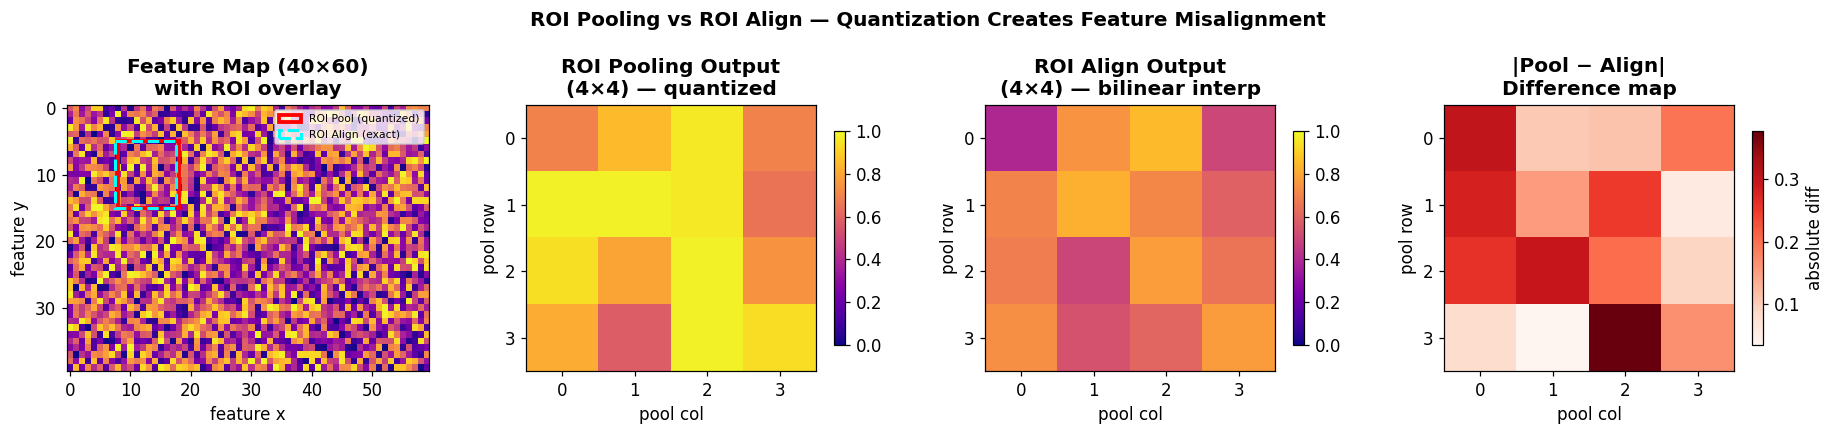

Saved: roi_align_comparison.png


In [9]:
# ─── ROI Align vs ROI Pool Visualisation ────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

# Feature map with ROI
ax = axes[0]
ax.imshow(test_feat[0], cmap='plasma', aspect='auto')
ax.set_title('Feature Map (40×60)\nwith ROI overlay', fontweight='bold')
fx1,fy1 = x1*SCALE, y1*SCALE
fw, fh  = (x2-x1)*SCALE, (y2-y1)*SCALE
# ROI Pool (quantized — red)
qx1 = round(x1*SCALE); qy1 = round(y1*SCALE)
qx2 = round(x2*SCALE); qy2 = round(y2*SCALE)
ax.add_patch(patches.Rectangle((qx1,qy1),qx2-qx1,qy2-qy1,
             lw=2.5, edgecolor='red', facecolor='none', label='ROI Pool (quantized)'))
# ROI Align (exact — cyan)
ax.add_patch(patches.Rectangle((fx1,fy1),fw,fh,
             lw=2, edgecolor='cyan', facecolor='none', linestyle='--', label='ROI Align (exact)'))
ax.legend(fontsize=7, loc='upper right')
ax.set_xlabel('feature x'); ax.set_ylabel('feature y')

# ROI Pool output
ax = axes[1]
im1 = ax.imshow(pooled_rp[0], cmap='plasma', aspect='auto', vmin=0, vmax=1)
ax.set_title('ROI Pooling Output\n(4×4) — quantized', fontweight='bold')
plt.colorbar(im1, ax=ax, shrink=0.8)
ax.set_xlabel('pool col'); ax.set_ylabel('pool row')

# ROI Align output
ax = axes[2]
im2 = ax.imshow(pooled_ra[0], cmap='plasma', aspect='auto', vmin=0, vmax=1)
ax.set_title('ROI Align Output\n(4×4) — bilinear interp', fontweight='bold')
plt.colorbar(im2, ax=ax, shrink=0.8)
ax.set_xlabel('pool col'); ax.set_ylabel('pool row')

# Difference map
ax = axes[3]
im3 = ax.imshow(diff[0], cmap='Reds', aspect='auto')
ax.set_title('|Pool − Align|\nDifference map', fontweight='bold')
plt.colorbar(im3, ax=ax, shrink=0.8, label='absolute diff')
ax.set_xlabel('pool col'); ax.set_ylabel('pool row')

plt.suptitle('ROI Pooling vs ROI Align — Quantization Creates Feature Misalignment',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roi_align_comparison.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: roi_align_comparison.png')

---
## 5. Faster R-CNN with torchvision

### torchvision Faster R-CNN Architecture

The torchvision implementation uses **Feature Pyramid Network (FPN)** on top of ResNet-50 — a modern improvement over the original single-scale Faster R-CNN:

```
ResNet-50 Backbone (C1→C5)
      │
FPN Neck ──► P2, P3, P4, P5, P6  (multi-scale feature maps)
      │
  ┌───┴───┐
 RPN     Detection Head
  │       │
proposals  ROI Align on each FPN level
           │
       Box head (2-FC)
           │
       cls scores + box deltas
```

**FPN advantage:** different FPN levels handle objects at different scales — P2 detects small objects (high resolution), P6 detects large objects (low resolution).

### COCO Classes (80 categories)
The pretrained model detects all 80 COCO classes: person, car, truck, bicycle, dog, cat, ... and 75 more.

In [10]:
# ─── Faster R-CNN Architecture Inspection ───────────────────────────────────
# weights=None → architecture only, no download

model = det_models.fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None)
model.eval()

# Parameter count by component
def count_params(module):
    return sum(p.numel() for p in module.parameters())

backbone_params = count_params(model.backbone)
rpn_params      = count_params(model.rpn)
roi_params      = count_params(model.roi_heads)
total_params    = count_params(model)

print('Faster R-CNN (ResNet-50 + FPN) Architecture')
print('=' * 50)
print(f'  Backbone (ResNet-50 + FPN) : {backbone_params/1e6:.1f}M params')
print(f'  RPN                        : {rpn_params/1e6:.1f}M params')
print(f'  ROI Heads                  : {roi_params/1e6:.1f}M params')
print(f'  Total                      : {total_params/1e6:.1f}M params')
print()
print('Key sub-modules:')
print(f'  model.backbone       : {type(model.backbone).__name__}')
print(f'  model.rpn            : {type(model.rpn).__name__}')
print(f'  model.rpn.anchor_generator.sizes    : {model.rpn.anchor_generator.sizes}')
print(f'  model.rpn.anchor_generator.aspect_ratios: {model.rpn.anchor_generator.aspect_ratios}')
print(f'  model.roi_heads.box_predictor       : {type(model.roi_heads.box_predictor).__name__}')
print()
print('FPN output feature levels: P2, P3, P4, P5, P6')
print('  P2 (stride  4) — for small objects')
print('  P3 (stride  8)')
print('  P4 (stride 16)')
print('  P5 (stride 32)')
print('  P6 (stride 64) — for large objects  (RPN only)')

Faster R-CNN (ResNet-50 + FPN) Architecture
  Backbone (ResNet-50 + FPN) : 26.9M params
  RPN                        : 0.6M params
  ROI Heads                  : 14.4M params
  Total                      : 41.8M params

Key sub-modules:
  model.backbone       : BackboneWithFPN
  model.rpn            : RegionProposalNetwork
  model.rpn.anchor_generator.sizes    : ((32,), (64,), (128,), (256,), (512,))
  model.rpn.anchor_generator.aspect_ratios: ((0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0))
  model.roi_heads.box_predictor       : FastRCNNPredictor

FPN output feature levels: P2, P3, P4, P5, P6
  P2 (stride  4) — for small objects
  P3 (stride  8)
  P4 (stride 16)
  P5 (stride 32)
  P6 (stride 64) — for large objects  (RPN only)


In [11]:
# ─── Faster R-CNN Forward Pass Demo ─────────────────────────────────────────
# Run with untrained weights on a synthetic image to show input/output structure.
# With pretrained weights the boxes would correspond to real COCO objects.

# Create two synthetic test images of different sizes (Faster R-CNN handles variable sizes)
img1 = torch.rand(3, 480, 640)   # 640×480 image (C, H, W)
img2 = torch.rand(3, 360, 480)   # 480×360 image

with torch.no_grad():
    predictions = model([img1, img2])   # list of images → list of prediction dicts

print('Output structure (one dict per image):')
for i, pred in enumerate(predictions):
    print(f'\n  Image {i+1}  ({[3,480,640][0]}×{[480,360][i]}×{[640,480][i]})')
    print(f'    boxes  : {pred["boxes"].shape}   — [x1,y1,x2,y2] in image coords')
    print(f'    labels : {pred["labels"].shape}  — COCO class index (1–90)')
    print(f'    scores : {pred["scores"].shape}  — confidence after NMS')
    if len(pred['scores']) > 0:
        print(f'    top-3 scores: {pred["scores"][:3].numpy().round(4)}')
        print(f'    top-3 boxes : {pred["boxes"][:3].numpy().round(1)}')

print('\nNote: untrained model → random predictions.')
print('With pretrained COCO weights, boxes would tightly surround real objects.')

Output structure (one dict per image):

  Image 1  (3×480×640)
    boxes  : torch.Size([100, 4])   — [x1,y1,x2,y2] in image coords
    labels : torch.Size([100])  — COCO class index (1–90)
    scores : torch.Size([100])  — confidence after NMS
    top-3 scores: [0.9886 0.9466 0.8894]
    top-3 boxes : [[ 65.9 231.6  97.4 292.3]
 [298.5 445.1 303.2 480. ]
 [523.8   0.  525.4  37.6]]

  Image 2  (3×360×480)
    boxes  : torch.Size([100, 4])   — [x1,y1,x2,y2] in image coords
    labels : torch.Size([100])  — COCO class index (1–90)
    scores : torch.Size([100])  — confidence after NMS
    top-3 scores: [0.9588 0.8895 0.8312]
    top-3 boxes : [[143.1 292.1 148.1 360. ]
 [132.9 280.4 139.7 360. ]
 [457.5   0.  458.9  34. ]]

Note: untrained model → random predictions.
With pretrained COCO weights, boxes would tightly surround real objects.


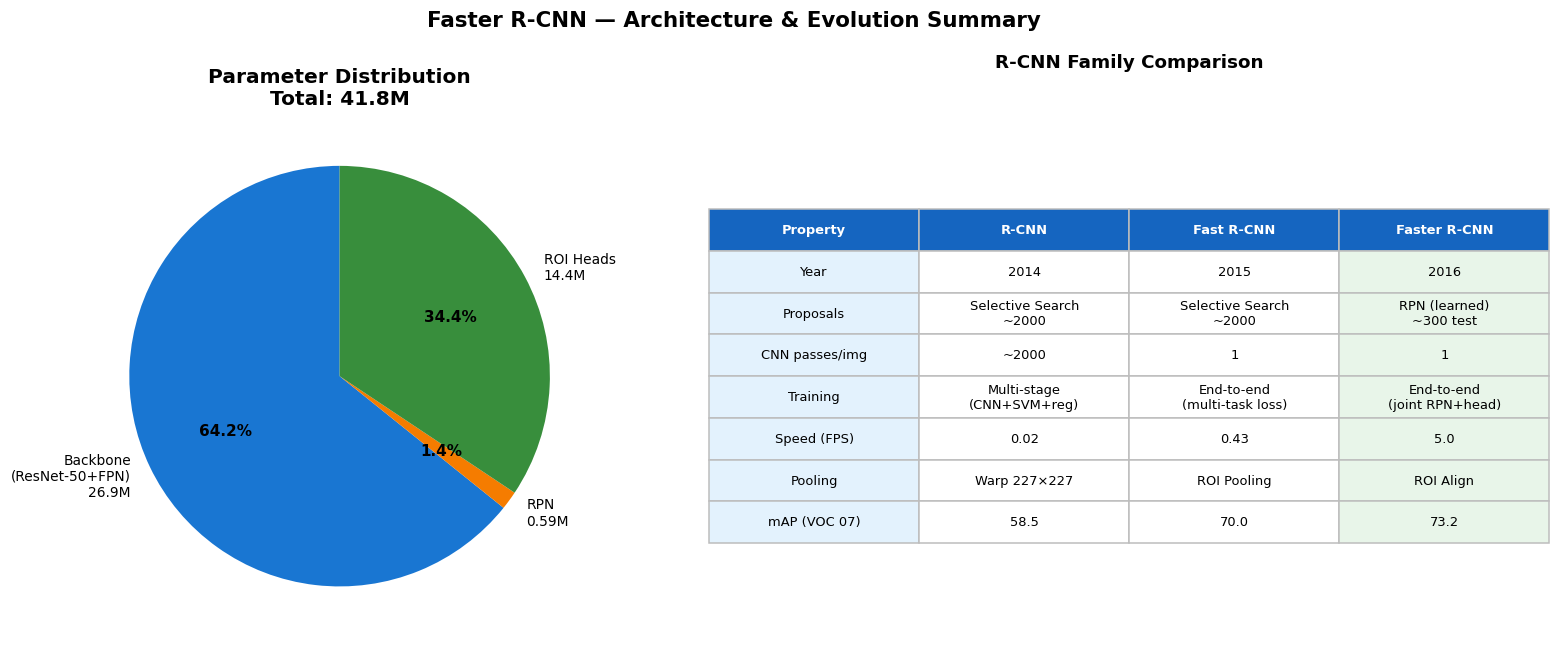

Saved: faster_rcnn_summary.png


In [12]:
# ─── Faster R-CNN Architecture Summary Figure ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: parameter breakdown pie chart
ax = axes[0]
sizes   = [backbone_params, rpn_params, roi_params]
labels  = [f'Backbone\n(ResNet-50+FPN)\n{backbone_params/1e6:.1f}M',
           f'RPN\n{rpn_params/1e6:.2f}M',
           f'ROI Heads\n{roi_params/1e6:.1f}M']
colors_pie = ['#1976D2', '#F57C00', '#388E3C']
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 9})
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax.set_title(f'Parameter Distribution\nTotal: {total_params/1e6:.1f}M', fontweight='bold')

# Right: architecture comparison table
ax = axes[1]
ax.axis('off')
headers = ['Property', 'R-CNN', 'Fast R-CNN', 'Faster R-CNN']
rows = [
    ['Year', '2014', '2015', '2016'],
    ['Proposals', 'Selective Search\n~2000', 'Selective Search\n~2000', 'RPN (learned)\n~300 test'],
    ['CNN passes/img', '~2000', '1', '1'],
    ['Training', 'Multi-stage\n(CNN+SVM+reg)', 'End-to-end\n(multi-task loss)', 'End-to-end\n(joint RPN+head)'],
    ['Speed (FPS)', '0.02', '0.43', '5.0'],
    ['Pooling', 'Warp 227×227', 'ROI Pooling', 'ROI Align'],
    ['mAP (VOC 07)', '58.5', '70.0', '73.2'],
]
tbl = ax.table(cellText=rows, colLabels=headers, cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.1, 2.2)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 0:
        cell.set_facecolor('#E3F2FD')
    elif col == 3:
        cell.set_facecolor('#E8F5E9')
    cell.set_edgecolor('#BDBDBD')
ax.set_title('R-CNN Family Comparison', fontweight='bold', fontsize=12, pad=30)

plt.suptitle('Faster R-CNN — Architecture & Evolution Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('faster_rcnn_summary.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: faster_rcnn_summary.png')

---
## Summary

### What we built today

| Component | Key Formula / Insight |
|-----------|----------------------|
| **R-CNN** | Selective search → 2000 proposals → 2000 CNN passes → SVM per class (47 s/img) |
| **Fast R-CNN** | One CNN pass over full image → ROI Pooling on shared feature map → 20× faster |
| **ROI Pooling** | Map ROI to feature map (quantize with `round`) → divide into bins → max-pool each |
| **Multi-task loss** | $L = L_{cls} + \lambda \cdot L_{loc}$  — Smooth L1 for robust box regression |
| **RPN** | 3×3 sliding window → 2 heads: objectness (bg/fg) + box deltas → top-K proposals |
| **Faster R-CNN** | Backbone + FPN + RPN + ROI Heads — all end-to-end, ~0.2 s/img |
| **ROI Align** | No quantization — bilinear interpolation at exact float coords — +3 mAP vs ROI Pool |

### Output files
- `rcnn_evolution.png` — selective search proposals + speed evolution bar chart
- `roi_pool_viz.png` — ROI Pooling demo + Smooth L1 vs L2 loss
- `rpn_visualization.png` — objectness heatmap + anchor boxes + proposal pipeline
- `roi_align_comparison.png` — Pool vs Align output + difference map
- `faster_rcnn_summary.png` — parameter breakdown + full comparison table

### Next — Wednesday (Jun 17): YOLO Architecture
YOLOv1→v8 evolution — grid-based single-shot detection, multi-scale heads, anchor-free design, and YOLOv8 fine-tuning on a custom dataset.